In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
df=pd.read_csv(r'C:\Users\Win-11\Downloads\spam_ham_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [2]:
print("Missing Values per Column:")
print(df.isnull().sum())
df.head()

Missing Values per Column:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


C:\Users\Win-11\AppData\Local\Temp\ipykernel_14680\1847750305.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label',data=df,palette='Set2')


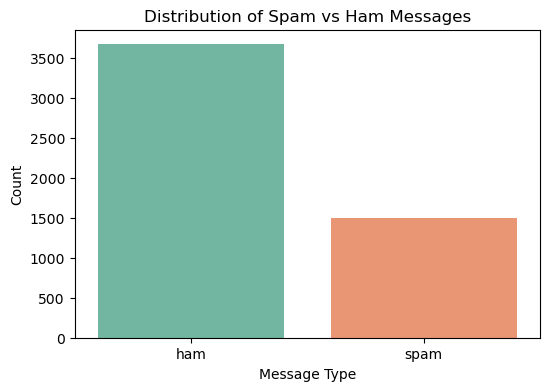

label
ham     71.01141
spam    28.98859
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='label',data=df,palette='Set2')
plt.title('Distribution of Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()
print(df['label'].value_counts(normalize=True) *100)

In [4]:
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z\s]','',text)
    words=text.split()
    cleaned_words=[word for word in words if word not in stop_words]
    return ' '.join(cleaned_words)
df['cleaned_text']=df['text'].apply(clean_text)
df[['text','cleaned_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Win-11\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,cleaned_text
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hpln...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...
4,Subject: re : indian springs\r\nthis deal is t...,subject indian springs deal book teco pvr reve...


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
X = df['cleaned_text']
y = df['label_num'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

print("Model trained successfully! 🎉")

Model trained successfully! 🎉


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

Naive Bayes Accuracy: 94.59%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       742
           1       0.89      0.93      0.91       293

    accuracy                           0.95      1035
   macro avg       0.93      0.94      0.93      1035
weighted avg       0.95      0.95      0.95      1035



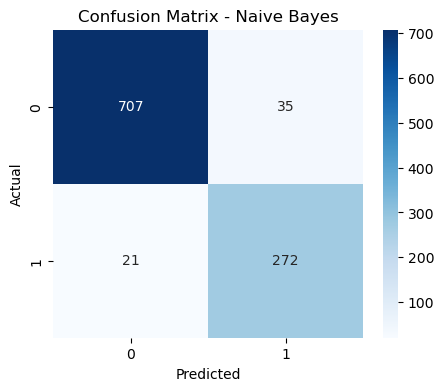

In [8]:

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [9]:
def predict_my_message(custom_message):
    cleaned = clean_text(custom_message)
    vectorized = vectorizer.transform([cleaned])
    prediction = nb_model.predict(vectorized)
    
    if prediction[0] == 1:
        return "Spam Message 🚨"
    else:
        return "Ham Message ✅"
email_1 = "Congratulations! You have won a 1000$ Walmart gift card. Click here to claim now."
print(f"Result 1: {predict_my_message(email_1)}")

email_2 = "Hello, are we still meeting for the project discussion today at 5 PM?"
print(f"Result 2: {predict_my_message(email_2)}")

Result 1: Spam Message 🚨
Result 2: Ham Message ✅


In [10]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}% 🎉")

Naive Bayes Accuracy: 94.59%
Logistic Regression Accuracy: 97.87% 🎉
